In [17]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import legendre, roots_legendre
from src.fortran.reflectivity_benchmark import reflectivity_q
from src.utilities import get_critical_angles
from src.plot.plot_tools import plot_reflectivity

Layer 1 -> Layer 2: 52.34° (v=2400.0 m/s)
Layer 1 -> Layer 3: 40.93° (v=2900.0 m/s)
Minimum critical angle: 40.93°
reflectivity without free surface


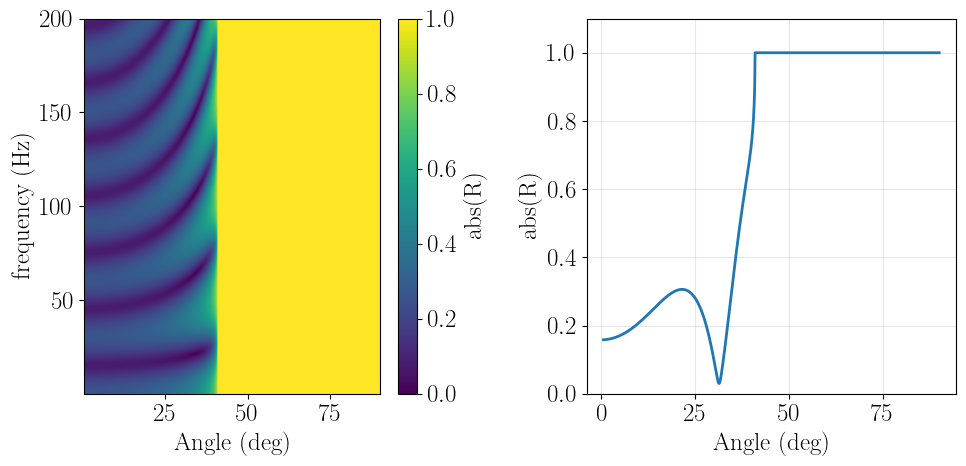

reflectivity with free surface at z=0


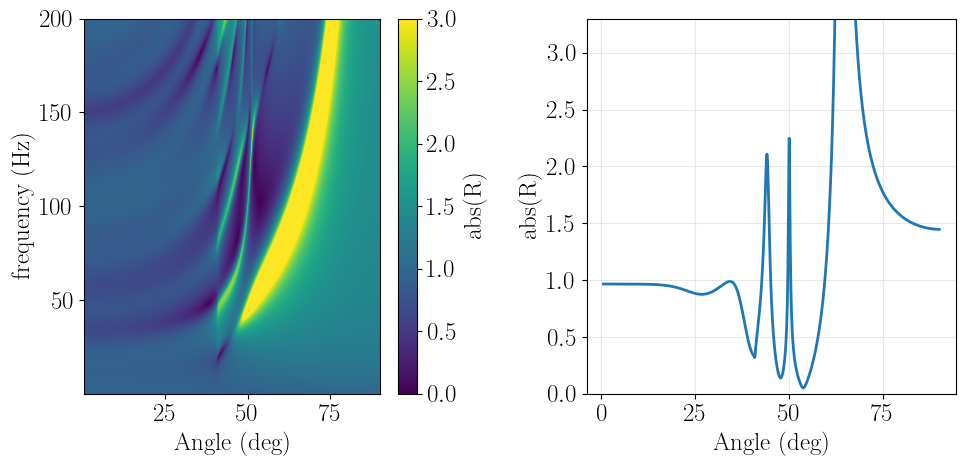

In [21]:
layers = [
        (100.0, 1900.0, 1800.0),
        (250.0, 2400.0, 2000.0),
        (350.0, 2900.0, 2000.0),
    ]
get_critical_angles(layers)

thetas = np.linspace(0.01, np.pi/2., 1024)  # 0-90 deg
omegas = np.linspace(0.1, 200, 1024)
p = np.sin(thetas) / layers[0][1]

print('reflectivity without free surface')
Rmap = reflectivity_q(layers, omegas, p, free_surface=0, zr=60., zs=60.)
plot_reflectivity(omegas, thetas, Rmap, omega_c=100., figsize=(10,5))

print('reflectivity with free surface at z=0')
alpha=4.
Rmap = reflectivity_q(layers, omegas+1j*alpha, p, free_surface=1, zr=60., zs=60.)
plot_reflectivity(omegas, thetas, Rmap, omega_c=100., figsize=(10,5))